# Brain Tumor MRI Classification

###  Import Libraries and Set Seed

In [ ]:
import os
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
import warnings

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


### Data Loading and Exploration

### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/brain-tumor-mri-dataset"
print("Classes:", os.listdir(dataset_path))


Classes: ['meningioma', 'pituitary', 'glioma', 'notumor']


#### Explore Dataset Structure and Class Distribution

In [ ]:
data_dir = pathlib.Path(dataset_path)
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print("Class names:", class_names)

class_counts = []
for class_name in class_names:
    count = len(list((data_dir / class_name).glob('*')))
    class_counts.append(count)
    print(f"{class_name}: {count} images")

print(f"\nTotal images: {sum(class_counts)}")

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
glioma: 1621 images
meningioma: 1777 images
notumor: 2000 images
pituitary: 1757 images

Total images: 7155


#### Class Distribution Visualization

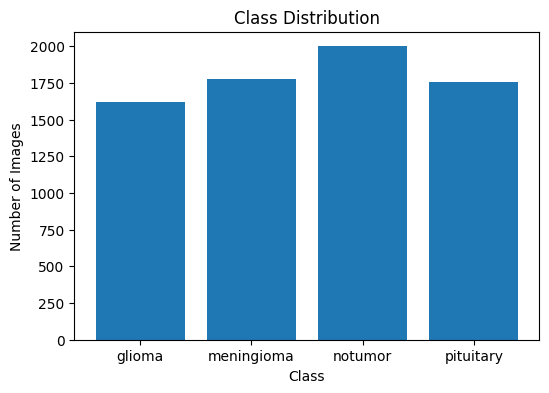

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(class_names, class_counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

#### Visualize Sample Images per Class

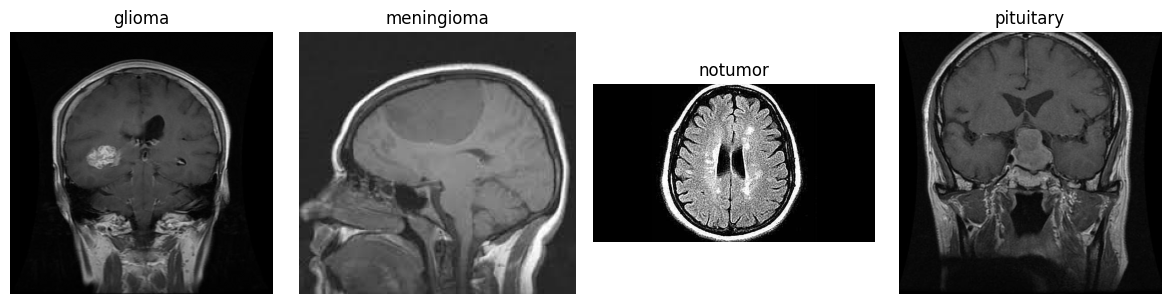

In [ ]:
# Show one sample image per class
plt.figure(figsize=(12, 3))
for i, class_name in enumerate(class_names):
    class_path = data_dir / class_name
    image_path = next(class_path.glob('*'))
    image = plt.imread(str(image_path))
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()


### Data Preparation

In [ ]:
from sklearn.model_selection import train_test_split

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class_to_index = {name: idx for idx, name in enumerate(class_names)}

all_paths, all_labels = [], []
for class_name in class_names:
    for img_path in (data_dir / class_name).glob('*'):
        all_paths.append(str(img_path))
        all_labels.append(class_to_index[class_name])

# 70% train, 15% val, 15% test — stratified so class ratios are preserved in each split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")


Train: 5008  Val: 1073  Test: 1074


#### Define Image Loading and Preprocessing Functions

In [ ]:
def load_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds

#### Create and Optimize TensorFlow Datasets

In [ ]:
train_dataset = make_dataset(train_paths, train_labels, shuffle=True)
val_dataset = make_dataset(val_paths, val_labels)
test_dataset = make_dataset(test_paths, test_labels)


train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

#### Verify Data Loading with a Sample Batch

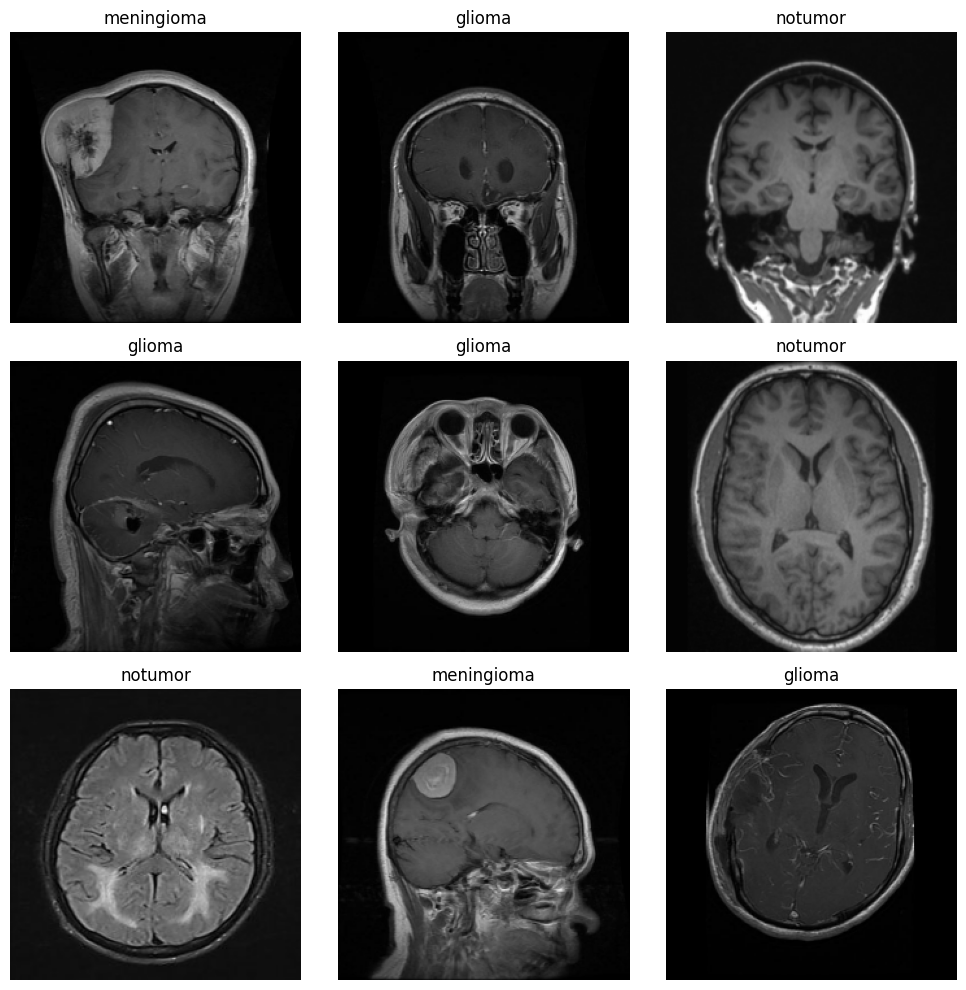

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [ ]:
# Sanity check: view a batch
image_batch, label_batch = next(iter(train_dataset))
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[label_batch[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

print("Image batch shape:", image_batch.shape)
print("Label batch shape:", label_batch.shape)


#### Calculate Class Weights for Imbalanced Data

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.1040564373897708), 1: np.float64(1.0064308681672025), 2: np.float64(0.8942857142857142), 3: np.float64(1.0178861788617886)}


### Model Definition and Training

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

cnn_model = tf.keras.Sequential([
    layers.Rescaling(1.0 / 255, input_shape=(*IMAGE_SIZE, 3)),  # normalize inside the model
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation="softmax")
])

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile the CNN Model

In [ ]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


#### Define Training Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)


#### Train the Model with Callbacks

In [ ]:
history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)


Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 723s 5s/step - accuracy: 0.3976 - loss: 1.2426 - val_accuracy: 0.4343 - val_loss: 1.1203 - learning_rate: 0.0010
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.5841 - loss: 0.9973 - val_accuracy: 0.5163 - val_loss: 1.0650 - learning_rate: 0.0010
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.6420 - loss: 0.8881 - val_accuracy: 0.6151 - val_loss: 0.9306 - learning_rate: 0.0010
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6771 - loss: 0.8217 - val_accuracy: 0.5405 - val_loss: 1.0681 - learning_rate: 0.0010
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.6975 - loss: 0.7761 - val_accuracy: 0.5993 - val_loss: 0.9679 - learning_rate: 0.0010
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7059 - loss: 0.7400 - val_accuracy: 0.6356 - val_loss: 0.9099 - learning_rate: 0.0010
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.7179 - loss: 0.

### Model Evaluation

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


34/34 ━━━━━━━━━━━━━━━━━━━━ 132s 4s/step - accuracy: 0.7058 - loss: 0.7419
Test Loss: 0.7419
Test Accuracy: 0.7058


#### Visualize Training and Validation Metrics

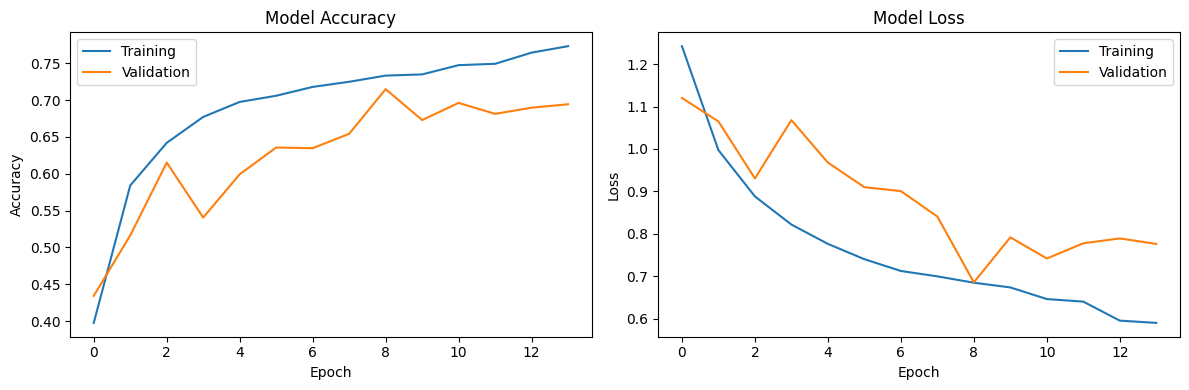

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


#### Generate Confusion Matrix and Classification Report

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


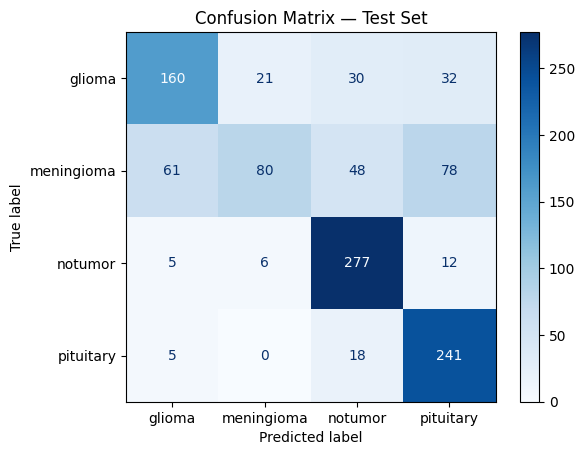

              precision    recall  f1-score   support

      glioma       0.69      0.66      0.68       243
  meningioma       0.75      0.30      0.43       267
     notumor       0.74      0.92      0.82       300
   pituitary       0.66      0.91      0.77       264

    accuracy                           0.71      1074
   macro avg       0.71      0.70      0.67      1074
weighted avg       0.71      0.71      0.68      1074



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])
y_pred_probs = cnn_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


## Save The Trained Model

In [ ]:
model_save_path = '/content/drive/MyDrive/cnn_model.keras'
cnn_model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/cnn_model.keras
